In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np

from meta import ROOT_DIR
from sketchy.prepare import (
    BinarySketchPredictor,
    compute_thickness_map,
    load_normalized,
)

# Walkthrough of the pipeline

This project aims to (re-)implement this paper: [Fidelity vs. Simplicity: a Global Approach to Line Drawing Vectorization](https://www-sop.inria.fr/reves/Basilic/2016/FLB16/fidelity_simplicity.pdf)

In this notebook, we will try to give a complete overview of the techniques used and the implementation choices in order to do it.

We strongly advise to read the paper a first time before looking at the notebook. Except for some details, it is well written and have nice illustrations

## Pipeline

Let's start with the central idea: we want to take a photography of a sketch as input, and return a SVG made up of a few curves

![](../images/illustration_butterfly.png)

In a nushell, here is what we do:
- we apply **preprocessing** to translate the image into a black and white mask
- we create a **skeleton** and convert it to a graph (chains of pixels)
- we use **hypergraph optimization** to find the optimal curves to approximate these chains of pixels

Here is the image we will use for demonstration purposes:

In [ ]:
def show(ax, title, axis=False):
    ax.axis("equal")
    ax.axis(axis)
    if not ax.yaxis_inverted():
        ax.invert_yaxis()
    ax.set_title(title)
    return mo.mpl.interactive(ax)

In [ ]:
img = load_normalized(ROOT_DIR / "data/sketches/butterfly.png", size=256)
plt.imshow(img, cmap="binary")
plt.colorbar()
show(plt.gca(), "original image", axis=True)

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327155366640/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327155366640/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327155366640/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327155366640/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327155366640/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327155366640/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327155366640/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327155366640");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327155366640,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

## Preprocessing

Before anything, we need a binary representation of our drawing.

The paper uses advanced trapped-ball and paint-filling techniques, but that would be a lot of work, to be honnest. And not that interesting !

At this point, I was wondering: what if we cloud cheat ? Going from someone's drawing to a logo-like black and white image sounds a lot like a [Style transfer](https://en.wikipedia.org/wiki/Neural_style_transfer):

![](https://s3.amazonaws.com/book.keras.io/img/ch8/style_transfer.png)

We are in 2025 after all, since we don't have a huge brain and a lot of time, maybe we could use a GPU and a lot of data instead ?

So, that's what we did !


Basically, we followed a simple recipe:
1. Get a good quality SVG dataset
2. Convert the SVG to a sketch-like black and white representation
3. Add different kind of noises and texture to simulate drawing on paper
4. Train a CNN to denoise the images.

This was not very hard conceptually, if you're curious you can look at the notebooks "cnn.py" and "svg_dataset.py" in one of these places:
- https://github.com/rambip/sketch-vectorization/tree/main/notebooks/ -> the code
- https://github.com/rambip/sketch-vectorization/tree/main/notebooks/__marimo__ -> the exported notebooks

In [ ]:
_details = mo.as_html(
    mo.md("""
- the noise must really look like your test images. Otherwise, you're too much out of distribution and the model can't learn properly.
- There is a tradeoff for the resolution: we want a model that can process large images, but it's more costly to train.
- **Don't try a small model**. I thought that a model with an inner dimension of 8 and 4 layers was enough, but it was not the case. Don't fear the overfitting: if you train for long enough and you have diverse enough datapoints, your model will generalize even if it has a lot of parameters. If that seems counter-intuitive to you, go read about [Double Descent](https://en.wikipedia.org/wiki/Double_descent)
- residual connections work really well. We ended up adding them at each layer.

We ended up with:
- 3000 data points of 256x256
- 8 layers of 3x3 convolutions
- an inner dimension of 32
- SiLU activation function
- 30 epochs, with a batch size of 50
- running on T4 gpus for something like 15min
""")
)
mo.md(f"""
<details>
<summary>
In a nutshell, a few lessons we learned:
</summary>
{_details.text}
</details>

But now, let's try it !

We converted it to ONNX format, so it can run without a gpu.
""")

<span class="markdown prose dark:prose-invert contents"><details>
<summary>
In a nutshell, a few lessons we learned:
</summary>
<span class="markdown prose dark:prose-invert contents"><ul>
<li>the noise must really look like your test images. Otherwise, you're too much out of distribution and the model can't learn properly.</li>
<li>There is a tradeoff for the resolution: we want a model that can process large images, but it's more costly to train.</li>
<li><strong>Don't try a small model</strong>. I thought that a model with an inner dimension of 8 and 4 layers was enough, but it was not the case. Don't fear the overfitting: if you train for long enough and you have diverse enough datapoints, your model will generalize even if it has a lot of parameters. If that seems counter-intuitive to you, go read about <a href="https://en.wikipedia.org/wiki/Double_descent" rel="noopener noreferrer" target="_blank">Double Descent</a></li>
<li>residual connections work really well. We ended up adding them at each layer.</li>
</ul>
<span class="paragraph">We ended up with:</span>
<ul>
<li>3000 data points of 256x256</li>
<li>8 layers of 3x3 convolutions</li>
<li>an inner dimension of 32</li>
<li>SiLU activation function</li>
<li>30 epochs, with a batch size of 50</li>
<li>running on T4 gpus for something like 15min</li>
</ul></span>
</details>

<span class="paragraph">But now, let's try it !</span>
<span class="paragraph">We converted it to ONNX format, so it can run without a gpu.</span></span>

In [ ]:
classifier = BinarySketchPredictor(gaussian_blur_sigma=1)
proba = classifier.predict_proba(img)
plt.imshow(proba, cmap="binary")
plt.colorbar()
show(plt.gca(), "Predicted probability for each pixel")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327154750736/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327154750736/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327154750736/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327154750736/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327154750736/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327154750736/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327154750736/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327154750736");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327154750736,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

Since the model is not perfect, there are still a few artefacts in the image.
To remove them, we use a simple gaussian filter before thresholding.

In [ ]:
img_binary = classifier.predict(img)
plt.imshow(img_binary, cmap="binary")
show(plt.gca(), title="Predicted pixels")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327151490608/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327151490608/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327151490608/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327151490608/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327151490608/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327151490608/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327151490608/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327151490608");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327151490608,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

Next, we compute the thickness of the drawing using erosion. For each pixel $P$, we want to get the number of time we have to "erode" the image before $P$ disappear.

> Note: erosion consists in taking the minimum value of all pixels in a 3x3 neighborhood.

In [ ]:
thickness_map = compute_thickness_map(img_binary)
plt.imshow(thickness_map)
plt.colorbar()
show(plt.gca(), "Thickness of the drawing")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327145205200/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327145205200/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327145205200/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327145205200/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327145205200/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327145205200/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327145205200/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327145205200");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327145205200,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

In [ ]:
_skeleton_illustration = mo.Html("""
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 450 150" width="400px">
  <defs>
    <style>
      .grid-bg { fill: #e0e0e0; }
      .pixel { fill: black; stroke: #333; stroke-width: 1; }
      .touch { fill: #888; }
    </style>
  </defs>

  <!-- Grid 1 -->
  <g transform="translate(10, 10)">
    <rect class="grid-bg" width="130" height="130" rx="5"/>
    <g transform="translate(25, 25)">
      <!-- Pixels -->
      <rect class="pixel" x="28" y="28" width="24" height="24"/>
      <rect class="pixel" x="54" y="28" width="24" height="24"/>
      <rect class="pixel" x="2" y="54" width="24" height="24"/>
      <!-- Touch points -->
      <circle class="touch" cx="53" cy="40" r="5"/>
      <circle class="touch" cx="27" cy="53" r="5"/>
    </g>
  </g>

  <!-- Grid 2 -->
  <g transform="translate(160, 10)">
    <rect class="grid-bg" width="130" height="130" rx="5"/>
    <g transform="translate(25, 25)">
      <!-- Pixels -->
      <rect class="pixel" x="54" y="2" width="24" height="24"/>
      <rect class="pixel" x="28" y="28" width="24" height="24"/>
      <rect class="pixel" x="2" y="54" width="24" height="24"/>
      <!-- Touch points -->
      <circle class="touch" cx="53" cy="27" r="5"/>
      <circle class="touch" cx="27" cy="53" r="5"/>
    </g>
  </g>

  <!-- Grid 3 -->
  <g transform="translate(310, 10)">
    <rect class="grid-bg" width="130" height="130" rx="5"/>
    <g transform="translate(25, 25)">
      <!-- Pixels -->
      <rect class="pixel" x="2" y="28" width="24" height="24"/>
      <rect class="pixel" x="28" y="28" width="24" height="24"/>
      <rect class="pixel" x="54" y="28" width="24" height="24"/>
      <!-- Touch points -->
      <circle class="touch" cx="27" cy="40" r="5"/>
      <circle class="touch" cx="53" cy="40" r="5"/>
    </g>
  </g>
</svg>
""")
mo.md(rf"""
## Skeleton and topological graph

Once we have a nice black and white image, we can create the skeleton very easily using iterative thining.

> A **skeleton** is a new binary image where all pixels have only 2 neighbors, like this:

> {_skeleton_illustration}

Hopefuly, this is already implemented in `scikit-learn`.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="skeleton-and-topological-graph">Skeleton and topological graph</h2>
<span class="paragraph">Once we have a nice black and white image, we can create the skeleton very easily using iterative thining.</span>
<blockquote>
<span class="paragraph">A <strong>skeleton</strong> is a new binary image where all pixels have only 2 neighbors, like this:</span>
<span class="paragraph"><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 450 150" width="400px"> <defs> <style> .grid-bg { fill: #e0e0e0; } .pixel { fill: black; stroke: #333; stroke-width: 1; } .touch { fill: #888; } </style> </defs>  <!-- Grid 1 --> <g transform="translate(10, 10)"> <rect class="grid-bg" width="130" height="130" rx="5"/> <g transform="translate(25, 25)"> <!-- Pixels --> <rect class="pixel" x="28" y="28" width="24" height="24"/> <rect class="pixel" x="54" y="28" width="24" height="24"/> <rect class="pixel" x="2" y="54" width="24" height="24"/> <!-- Touch points --> <circle class="touch" cx="53" cy="40" r="5"/> <circle class="touch" cx="27" cy="53" r="5"/> </g> </g>  <!-- Grid 2 --> <g transform="translate(160, 10)"> <rect class="grid-bg" width="130" height="130" rx="5"/> <g transform="translate(25, 25)"> <!-- Pixels --> <rect class="pixel" x="54" y="2" width="24" height="24"/> <rect class="pixel" x="28" y="28" width="24" height="24"/> <rect class="pixel" x="2" y="54" width="24" height="24"/> <!-- Touch points --> <circle class="touch" cx="53" cy="27" r="5"/> <circle class="touch" cx="27" cy="53" r="5"/> </g> </g>  <!-- Grid 3 --> <g transform="translate(310, 10)"> <rect class="grid-bg" width="130" height="130" rx="5"/> <g transform="translate(25, 25)"> <!-- Pixels --> <rect class="pixel" x="2" y="28" width="24" height="24"/> <rect class="pixel" x="28" y="28" width="24" height="24"/> <rect class="pixel" x="54" y="28" width="24" height="24"/> <!-- Touch points --> <circle class="touch" cx="27" cy="40" r="5"/> <circle class="touch" cx="53" cy="40" r="5"/> </g> </g> </svg></span>
</blockquote>
<span class="paragraph">Hopefuly, this is already implemented in <code>scikit-learn</code>.</span></span>

In [ ]:
from scipy import signal
from skimage.morphology import skeletonize

from sketchy.bezier import fit_bezier, interpolate_bezier
from sketchy.topology import (
    extract_chains,
    refine_all_chains,
    remove_parasite_chains,
)

In [ ]:
skeleton = skeletonize(img_binary, method="zhang")

plt.imshow(skeleton, cmap="binary")
show(plt.gca(), "Skeleton of the sketch")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327153075488/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327153075488/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327153075488/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327153075488/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327153075488/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327153075488/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327153075488/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327153075488");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327153075488,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

Once we have this graph, we traverse it in order to get the pixel chains.

This is not explained explicitely in the original paper, but the trick is to look at the **number of neighbours** in the skeleton. Indeed, most nodes in the skeleton have only 2 neighbours. If it is not the case, we call it a "special" pixel or an "endpoint".

In [ ]:
kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])
neighbours = signal.convolve2d(skeleton.astype(int), kernel, mode="same")
neighbours = neighbours * skeleton

def pos_where(mask):
    return np.where(mask)[1], np.where(mask)[0]

plt.imshow(1 - skeleton, cmap="gray")
plt.scatter(
    *pos_where(neighbours == 1),
    label="1 neighbour",
    s=5,
)
plt.scatter(
    *pos_where(neighbours == 3),
    label="3 neighbours",
    s=5,
)
plt.scatter(
    *pos_where(neighbours > 3),
    label=">3 neighbours",
    s=5,
)
plt.legend()
show(plt.gca(), "skeleton with number of neighbours")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327146942288/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327146942288/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327146942288/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327146942288/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327146942288/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327146942288/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327146942288/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327146942288");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327146942288,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

We use this information to perform a graph traversal, from arbitrary pixels to these "special" pixels.
For the special case of loops, we break them into a chain that ends where it starts.

We get a list of pixel "chains":

> Note: we have to be careful about "clusters". If you zoom in on the previous image, you will see clusters of pixels with at least 3 neighbours. We merge them into one single mega-pixel when it's the case.

In [ ]:
pixel_chains = extract_chains(skeleton)
_ax = plt.gca()
for chain in pixel_chains:
    # chain is shape (N, 2) where each row is [row, col] or [y, x]
    _ax.plot(chain[:, 1], chain[:, 0], "-o", markersize=2, linewidth=1)

show(_ax, "Pixel chains")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327144780896/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144780896/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144780896/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144780896/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144780896/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144780896/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327144780896/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327144780896");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327144780896,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

Let's remove the pixel chains that are too small:

> Note: we only remove small pixel chains that don't affect the *connectivity*, like chains that have a dead end or multiple chains that start and end at the same place.

In [ ]:
pixel_chains_clean = remove_parasite_chains(pixel_chains, min_length=5)
ax_chain_clean = plt.gca()
for _chain in pixel_chains_clean:
    # chain is shape (N, 2) where each row is [row, col] or [y, x]
    ax_chain_clean.plot(_chain[:, 1], _chain[:, 0], "-o", markersize=2, linewidth=1)

show(ax_chain_clean, "Pixel chains (cheaned)")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327143979760/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327143979760/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327143979760");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327143979760,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

Now that he have a clean skeleton, the goal will be to approximate as well as possible using [Bezier curves](https://pomax.github.io/bezierinfo/).

We figured that fitting a bezier on a chain of pixel is pretty cheap once you have the right representation.

You want to minimize $\mathcal L(\omega) = \sum_t ||B(\omega)_t - C_t||^2$ where $\omega$ are the 8 parameters of our bezier curve, $B(\omega)$ is the list of positions of the bezier with parameters $\omega$, and $C$ is the list of positions in our pixel chains.

For a fixed $t$, we know that $\omega \to B(\omega)_t$ is linear, and we can construct the transformation matrix pretty easily. This means that the problems boils down to a **linear least-square problem** (see [this wiki page](https://en.wikipedia.org/wiki/Linear_least_squares#Applications) for more information)

In [ ]:
def show_fitted(ax, chain):
    # Fit Bézier curve
    instants = np.linspace(0, 1, len(chain))
    control_points = fit_bezier(chain, instants, degree=3)
    bezier_curve = interpolate_bezier(control_points, instants)

    # Plot the original pixels
    ax.plot(chain[:, 1], chain[:, 0], "o", markersize=3, alpha=0.3, color="gray")

    # Plot the Bézier curve
    ax.plot(
        bezier_curve[:, 1],
        bezier_curve[:, 0],
        "-",
        linewidth=1,
        alpha=1,
        color="red",
    )

In [ ]:
ax_fitted = plt.gca()
for _chain in pixel_chains_clean:
    show_fitted(ax_fitted, _chain)
show(ax_fitted, "Fitted Bézier Curves")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327156109648/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327156109648/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327156109648");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327156109648,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

This already looks pretty good, but we see that some curves fit better than other. This is because in our skeleton, some chains of pixels where very long and with complicated shapes.
To solve this problem, we split our pixel chains into pieces when the fitting error is too high.

Here is what we get:

In [ ]:
pixel_chains_refined = refine_all_chains(pixel_chains_clean, tolerance=2)
ax_chain_refined = plt.gca()
for _chain in pixel_chains_refined:
    # chain is shape (N, 2) where each row is [row, col] or [y, x]
    ax_chain_refined.plot(
        _chain[:, 1], _chain[:, 0], "-o", markersize=2, linewidth=1
    )
show(ax_chain_refined, "Pixel chains (refined)")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327144770048/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144770048/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144770048/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144770048/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144770048/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327144770048/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327144770048/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327144770048");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327144770048,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

The pixel chains seem simpler this way. Let's check that the curves fit better this time:

In [ ]:
ax_fitted_refined = plt.gca()
for _chain in pixel_chains_refined:
    show_fitted(ax_fitted_refined, _chain)

mo.vstack(
    [
        mo.hstack(
            [
                show(ax_chain_clean, "Pixel chains before refine").style(
                    {"width": "100%"}
                ),
                show(ax_fitted, "Fitted curves before refine").style(
                    {"width": "100%"}
                ),
            ]
        ),
        mo.hstack(
            [
                show(ax_chain_refined, "Pixel chains after refine").style(
                    {"width": "100%"}
                ),
                show(ax_fitted_refined, "Fitted curves after refine").style(
                    {"width": "100%"}
                ),
            ]
        ),
    ]
)

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327143979760/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327143979760/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327143979760/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327143979760");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327143979760,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'> <iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140327156109648/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140327156109648/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140327156109648/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140327156109648");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140327156109648,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && f

Now, we have to implement what is probably the most difficult part of the paper: the global optimisation.


We will manipulate sequences of edges, that we will call **hyperedges**. The intuition if they are multiple chains of pixels aligned with each other in the topological graph, they should be grouped together to form a longer chain.

This optimisation process is based on the idea of doing **perturbations** on these sequences.

Since the paper is not very explicit about these perturbations, we implemented it in a slightly different (but similar) way.

We first sample pairs of hyperedges $(U, V)$ such that $U$ end at a node that is anywhere inside $V$. We call such a configuation a "T" configuration.

![](../images/schema_t.svg)

Note that hyperedges are oriented. Once we sample one "T", we can apply 6 different transformations:

- increase or decrease the degree of $V$
- splitting V into 2 (if it has more than 3 nodes)
- overlaping V onto U (here, $V$ will become $(y, x, c, d)$)
- dissociating V from U (for that, the last edge of V must be in U)
- merging V and U. This is only possible when the T is in the special configuration showed below:

![](../images/schema_t2.svg)

We add a special transformation: **reverse**. As the name suggests, we reverse the order of all nodes in the sequence.

With the addition of this transformation, this is completely equivalent to the transformations proposed by the paper.


We try to chose the same parameters as the paper each time we can, to be able to compare results.

In [ ]:
from sketchy.optim import SketchOptimizer, SuperGraph, align_boundaries
from sketchy.viz import OptimPlayBack

In [ ]:
lam = 0.6
t_min = 0.003
mu = 0.3
t_decrease = 0.9997
optim = SketchOptimizer(lam=lam, t_min=t_min, mu=mu, t_decrease=t_decrease)
curves, mapping = optim.fit_transform(pixel_chains_refined)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13996/13996 [00:05<00:00, 2674.85it/s]


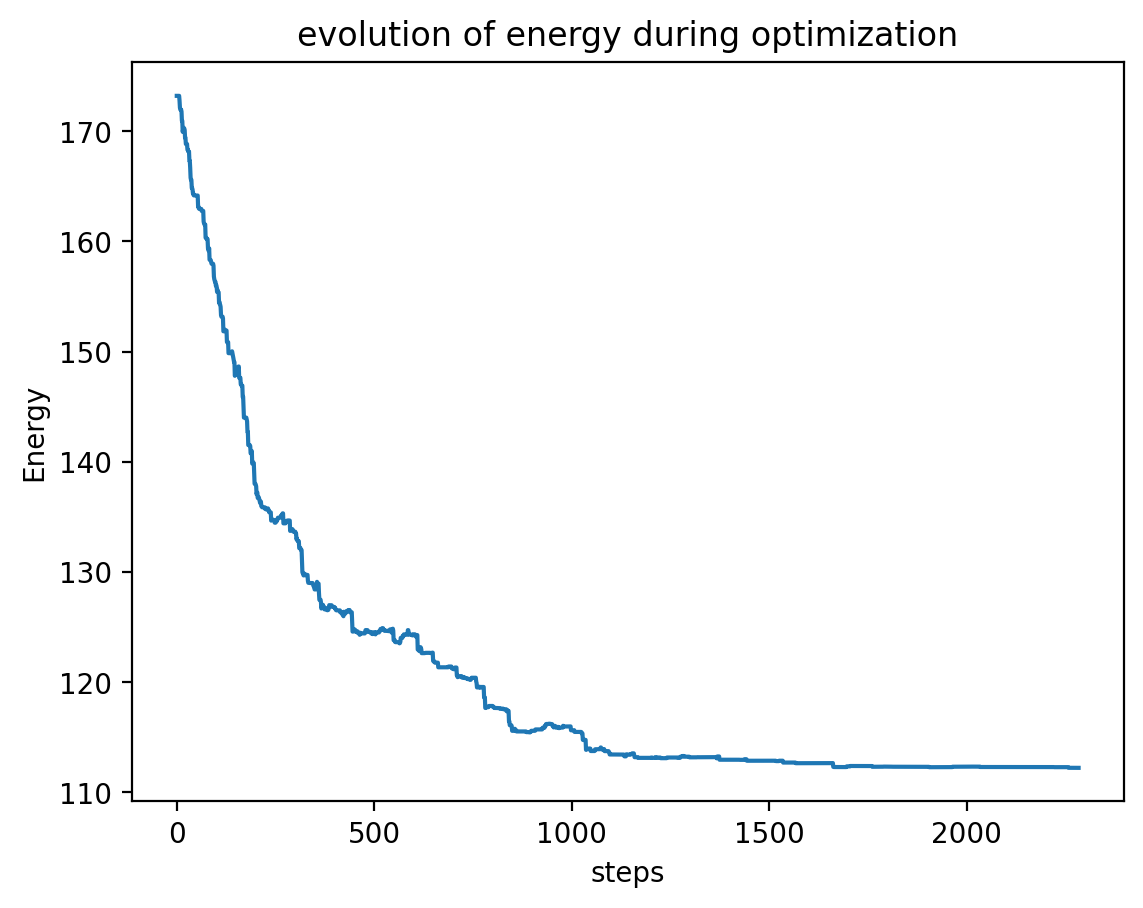

In [ ]:
plt.plot(range(len(optim.error_)), optim.error_)
plt.ylabel("Energy")
plt.xlabel("steps")
plt.title("evolution of energy during optimization")
plt.show()

In [ ]:
instants = np.linspace(0, 1, 100)
_ax = plt.gca()
for i, _c in enumerate(curves):
    bezier_curve = interpolate_bezier(_c.control_points, instants)

    # Plot the Bézier curve
    _ax.plot(bezier_curve[:, 1], bezier_curve[:, 0], "-", linewidth=1, alpha=1)
    _ax.text(
        bezier_curve[:, 1].mean(), bezier_curve[:, 0].mean(), str(i), fontsize=10
    )
show(_ax, "final curves")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140326984122320/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984122320/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984122320/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984122320/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984122320/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984122320/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140326984122320/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140326984122320");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140326984122320,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

In [ ]:
N = len(pixel_chains_refined)
f = mo.ui.anywidget(OptimPlayBack(pixel_chains_refined, optim.history_))
f

In [ ]:
from collections import Counter

Counter([x[0] for x in optim.history_])

Counter({np.int64(6): 1786, np.int64(1): 235, np.int64(0): 161, np.int64(2): 80, np.int64(3): 10, np.int64(4): 6, np.int64(5): 5})

If we look closely, we see that some lines do not join exactly at the same point. It is logical, since every curve fitting is independent.
The way to fix this problem is specified in the paper, but not exactly.

We chose to implement what seemed like a reasonnable solution.

First for the point-edges junctions, we look again at all our "T" configurations (see above) and force the control point of the incoming curve to fall exactly on the other curve.

For the point-point junctions, we compute the barycenter $B$ of all the points that are supposed to arrive at the same position, and we force the control point of each incoming edge to be $B$.

In [ ]:
final_curves = align_boundaries(curves, mapping)
_ax = plt.gca()
for _i, _c in enumerate(final_curves):
    _bezier_curve = interpolate_bezier(_c.control_points, instants)

    # Plot the Bézier curve
    _ax.plot(_bezier_curve[:, 1], _bezier_curve[:, 0], "-", linewidth=1, alpha=1)
show(_ax, "final curves")

<iframe srcdoc='<!DOCTYPE html>
<html lang="en">
 <head>
 <base href='http://localhost:2718/mpl/140326984106864/' />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984106864/_static/css/page.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984106864/_static/css/boilerplate.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984106864/_static/css/fbm.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984106864/_static/css/mpl.css" type="text/css" />
 <link rel="stylesheet" href="http://localhost:2718/mpl/140326984106864/custom.css" type="text/css" />
 <script src="http://localhost:2718/mpl/140326984106864/mpl.js"></script>

 <script>
 function ondownload(figure, format) {
 window.open('download.' + format + '?figure=' + figure.id, '_blank');
 };

 function ready(fn) {
 if (document.readyState != "loading") {
 fn();
 } else {
 document.addEventListener("DOMContentLoaded", fn);
 }
 }

 ready(
 function() {
 var websocket_type = mpl.get_websocket_type();
 var websocket = new websocket_type("ws://localhost:2718/mpl/10851/ws?figure=140326984106864");

 // mpl.figure creates a new figure on the webpage.
 var fig = new mpl.figure(
 // A unique numeric identifier for the figure
 140326984106864,
 // A websocket object
 websocket,
 // A function called when a file type is selected for download
 ondownload,
 // The HTML element in which to place the figure
 document.getElementById("figure"));

 // When the browser tab is hidden (minimized or switched away),
 // browsers throttle or skip canvas rendering. Any canvas updates
 // sent by matplotlib while hidden are effectively lost, leaving
 // blank plots. Re-request the full figure when the tab returns.
 document.addEventListener("visibilitychange", function() {
 if (!document.hidden && fig.ws.readyState === 1) {
 fig.send_message("refresh", {});
 }
 });
 }
 );
 </script>

 <title>marimo</title>
 </head>

 <body>
 <div id="figure"></div>
 </body>
</html>' width='100%' height='550px' onload='__resizeIframe(this)' frameborder='0'>

## SVG export

In [ ]:
from marimo import Html

from sketchy.export import export_svg
from sketchy.viz import show_example

In [ ]:
out = export_svg(final_curves, img.shape)
Html(out)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:04<00:00, 2969.92it/s]


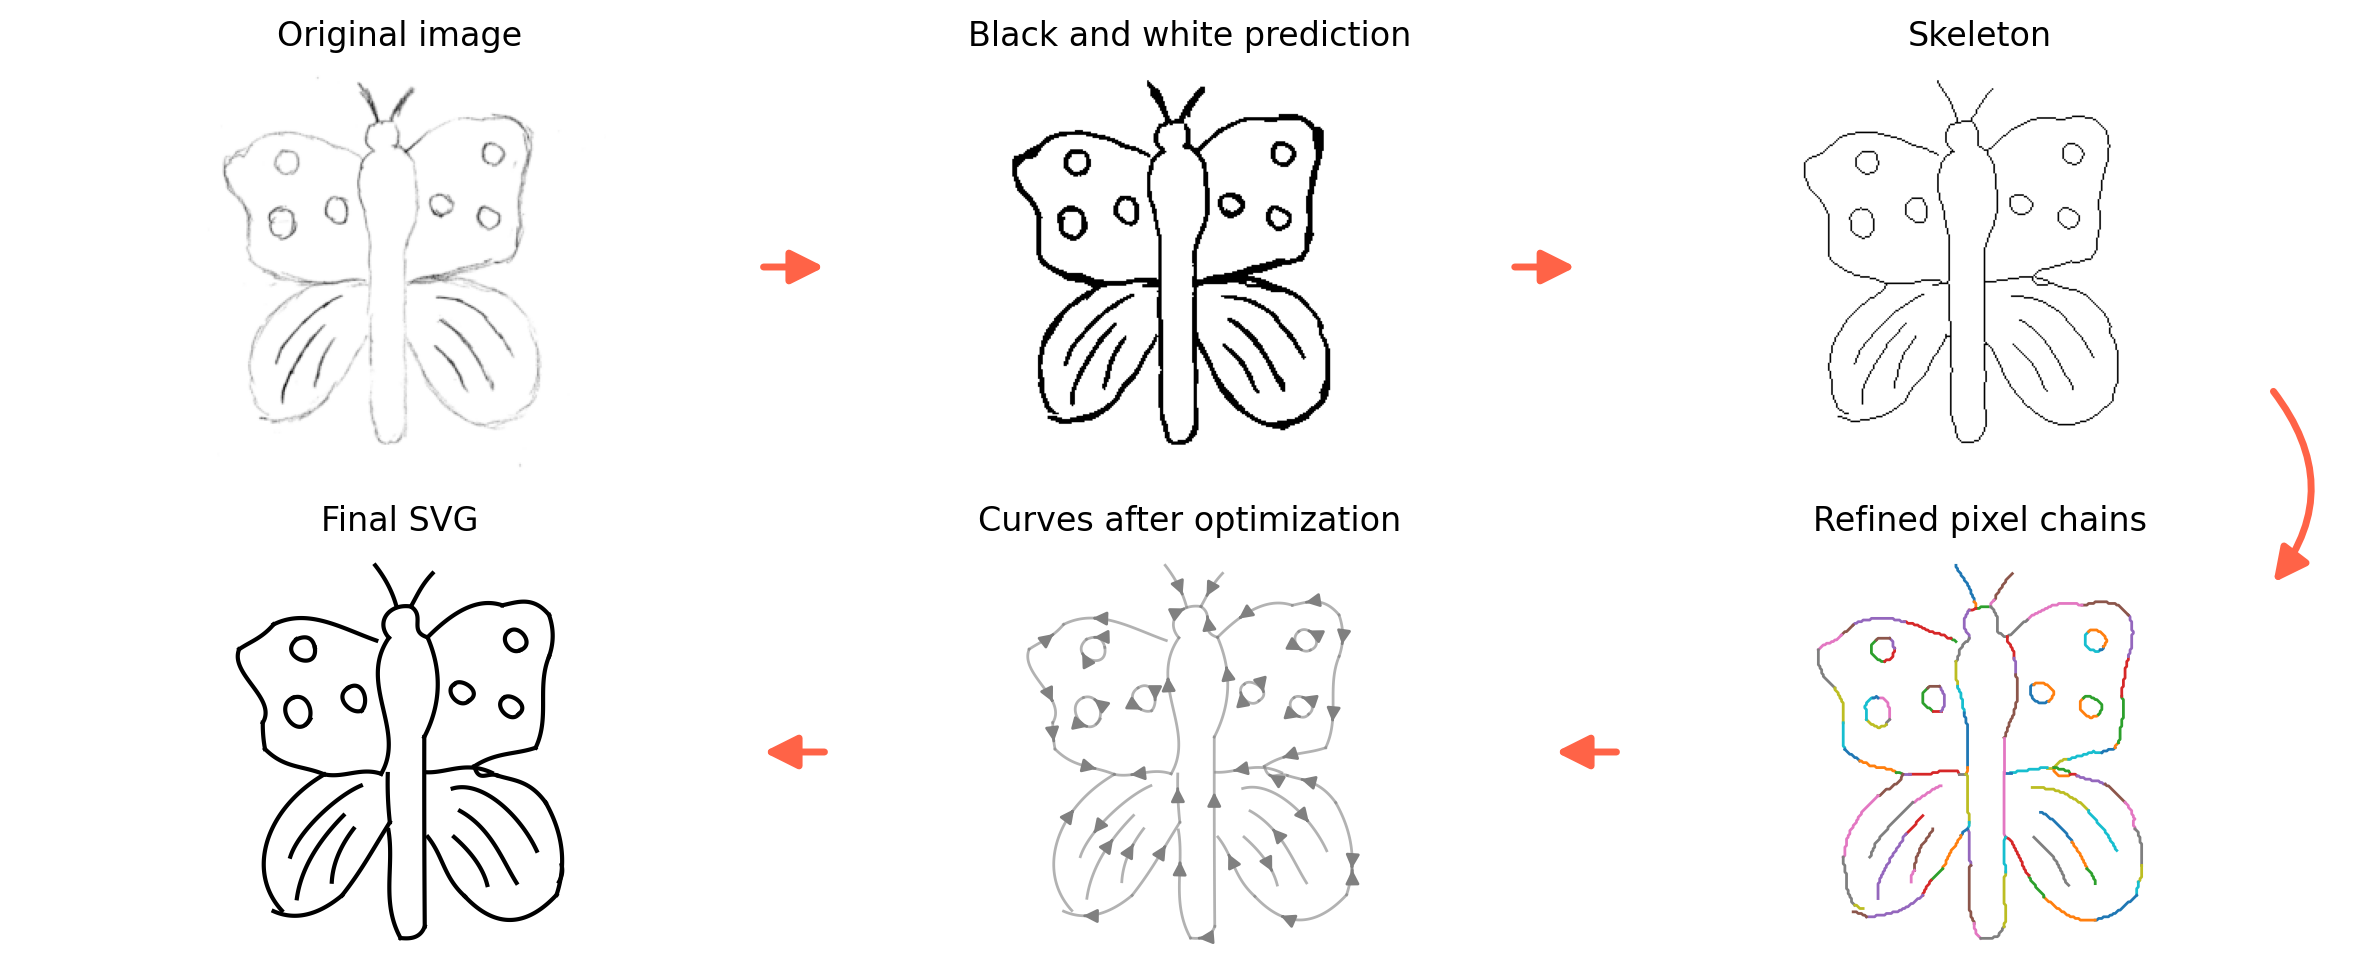

In [ ]:
show_example(ROOT_DIR / "data/sketches/butterfly.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:06<00:00, 1999.92it/s]


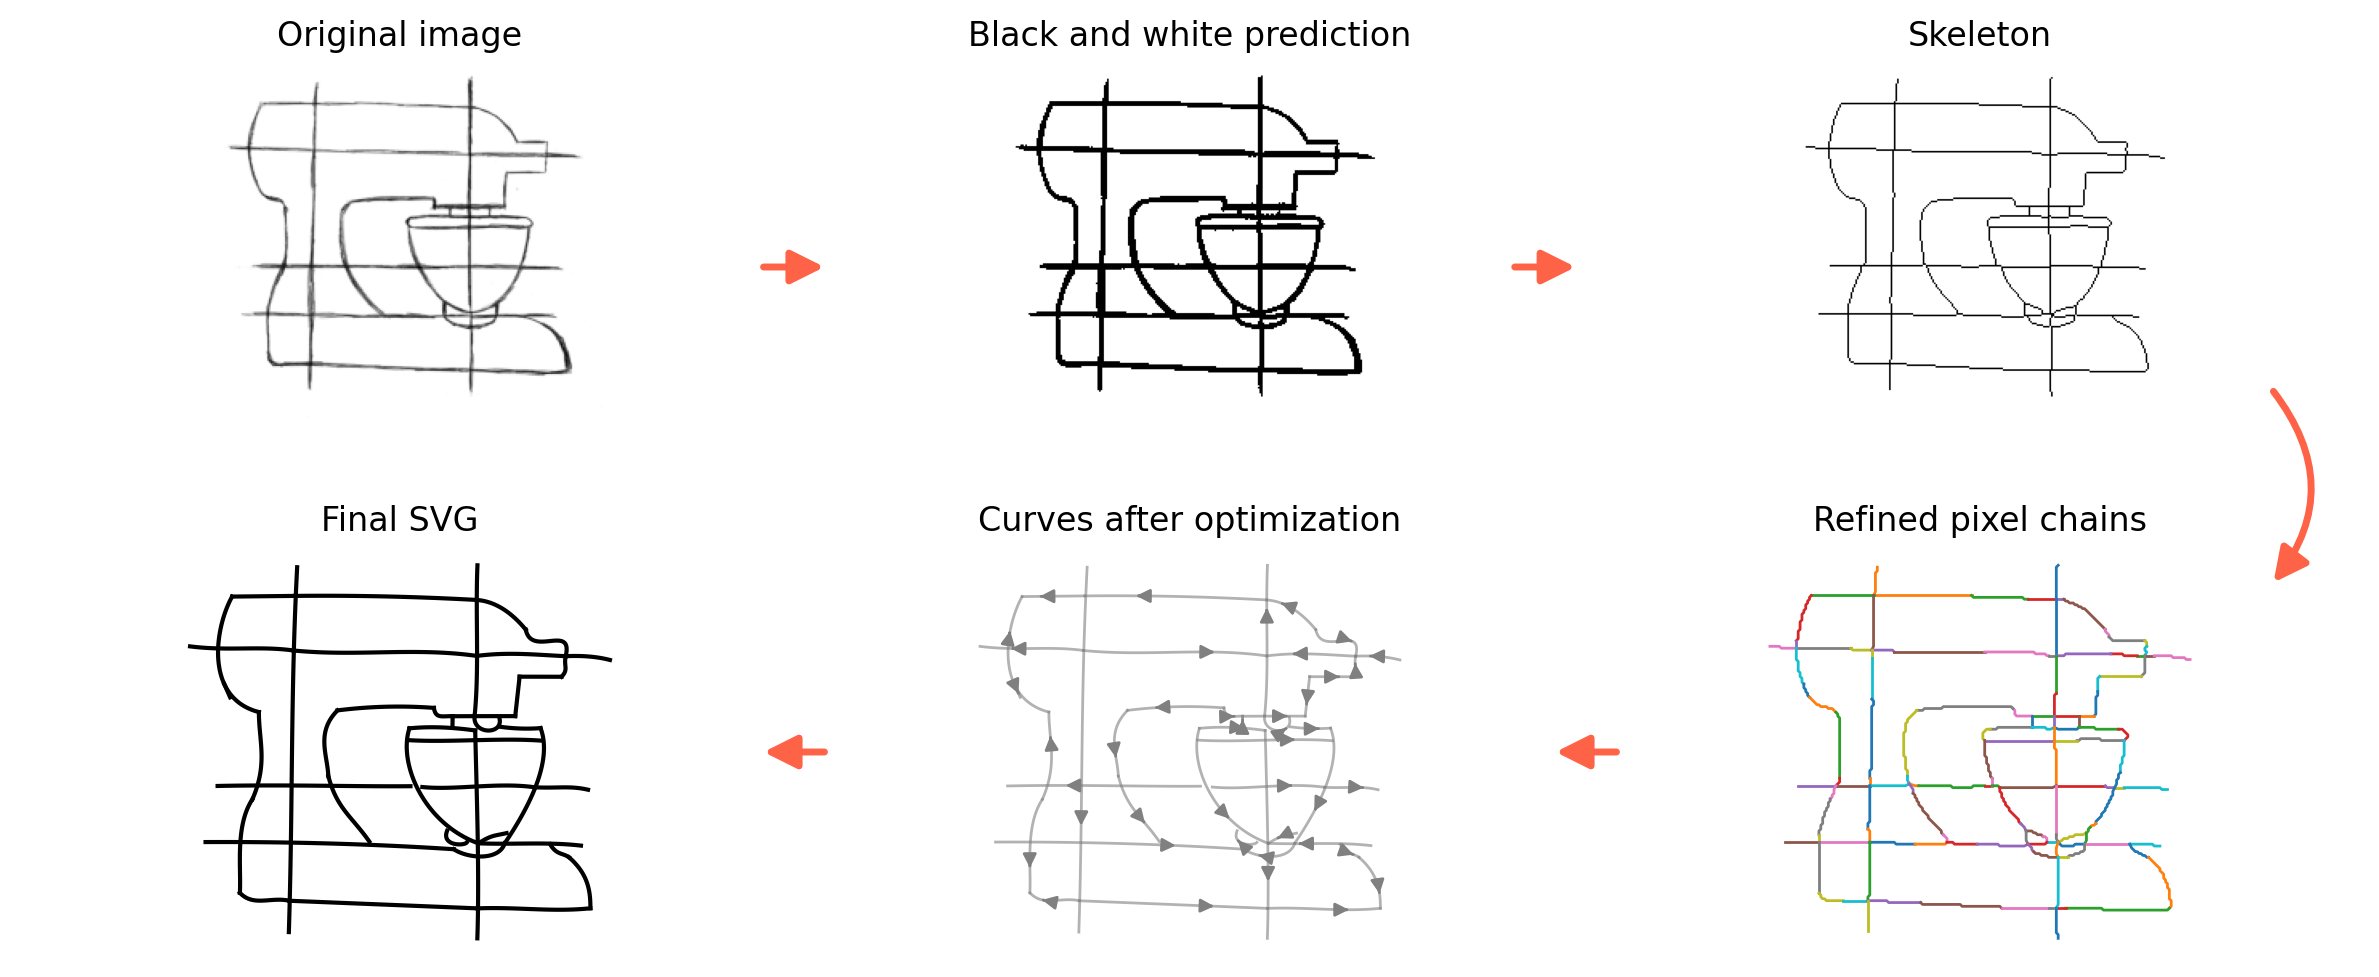

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_2/input.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:06<00:00, 2254.08it/s]


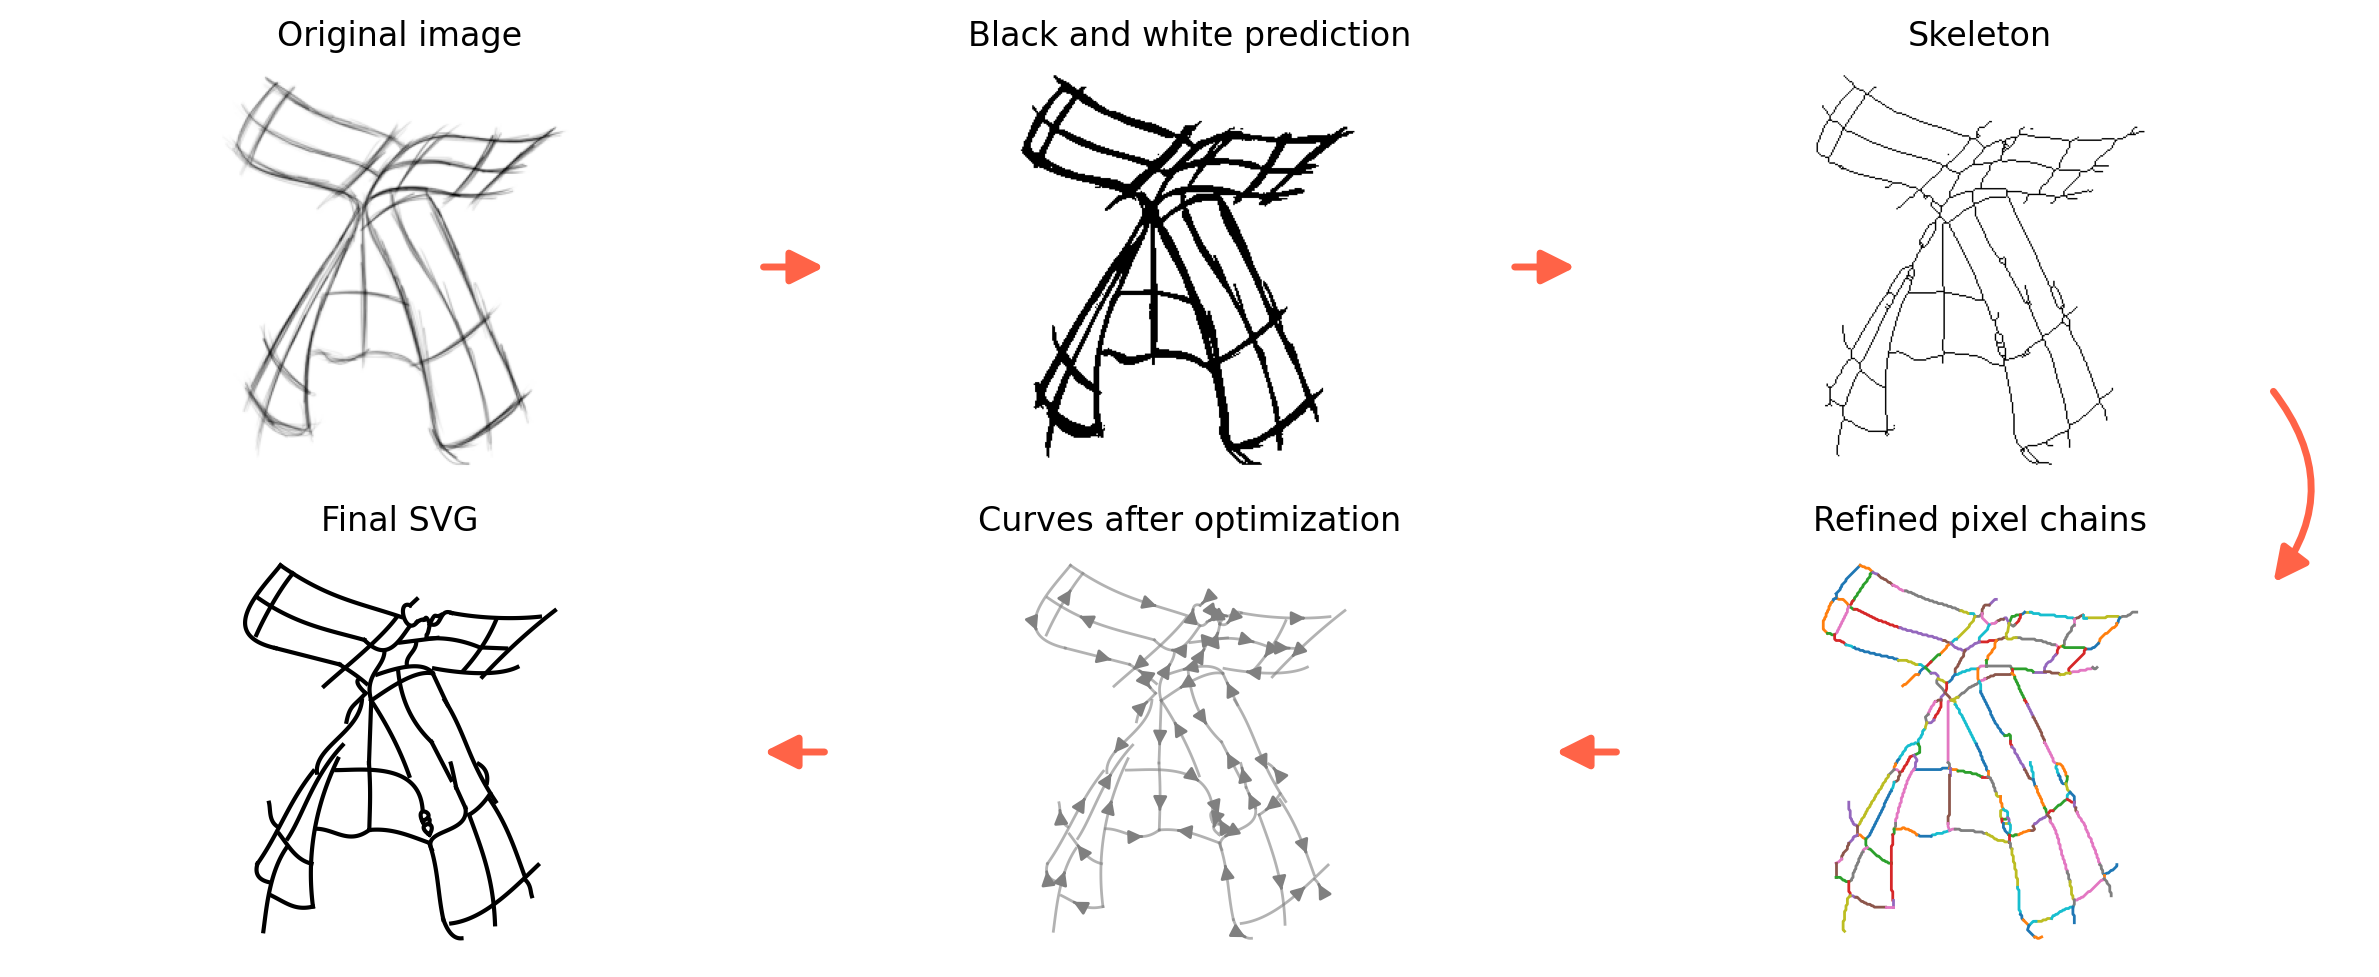

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_1/input.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:06<00:00, 2177.93it/s]


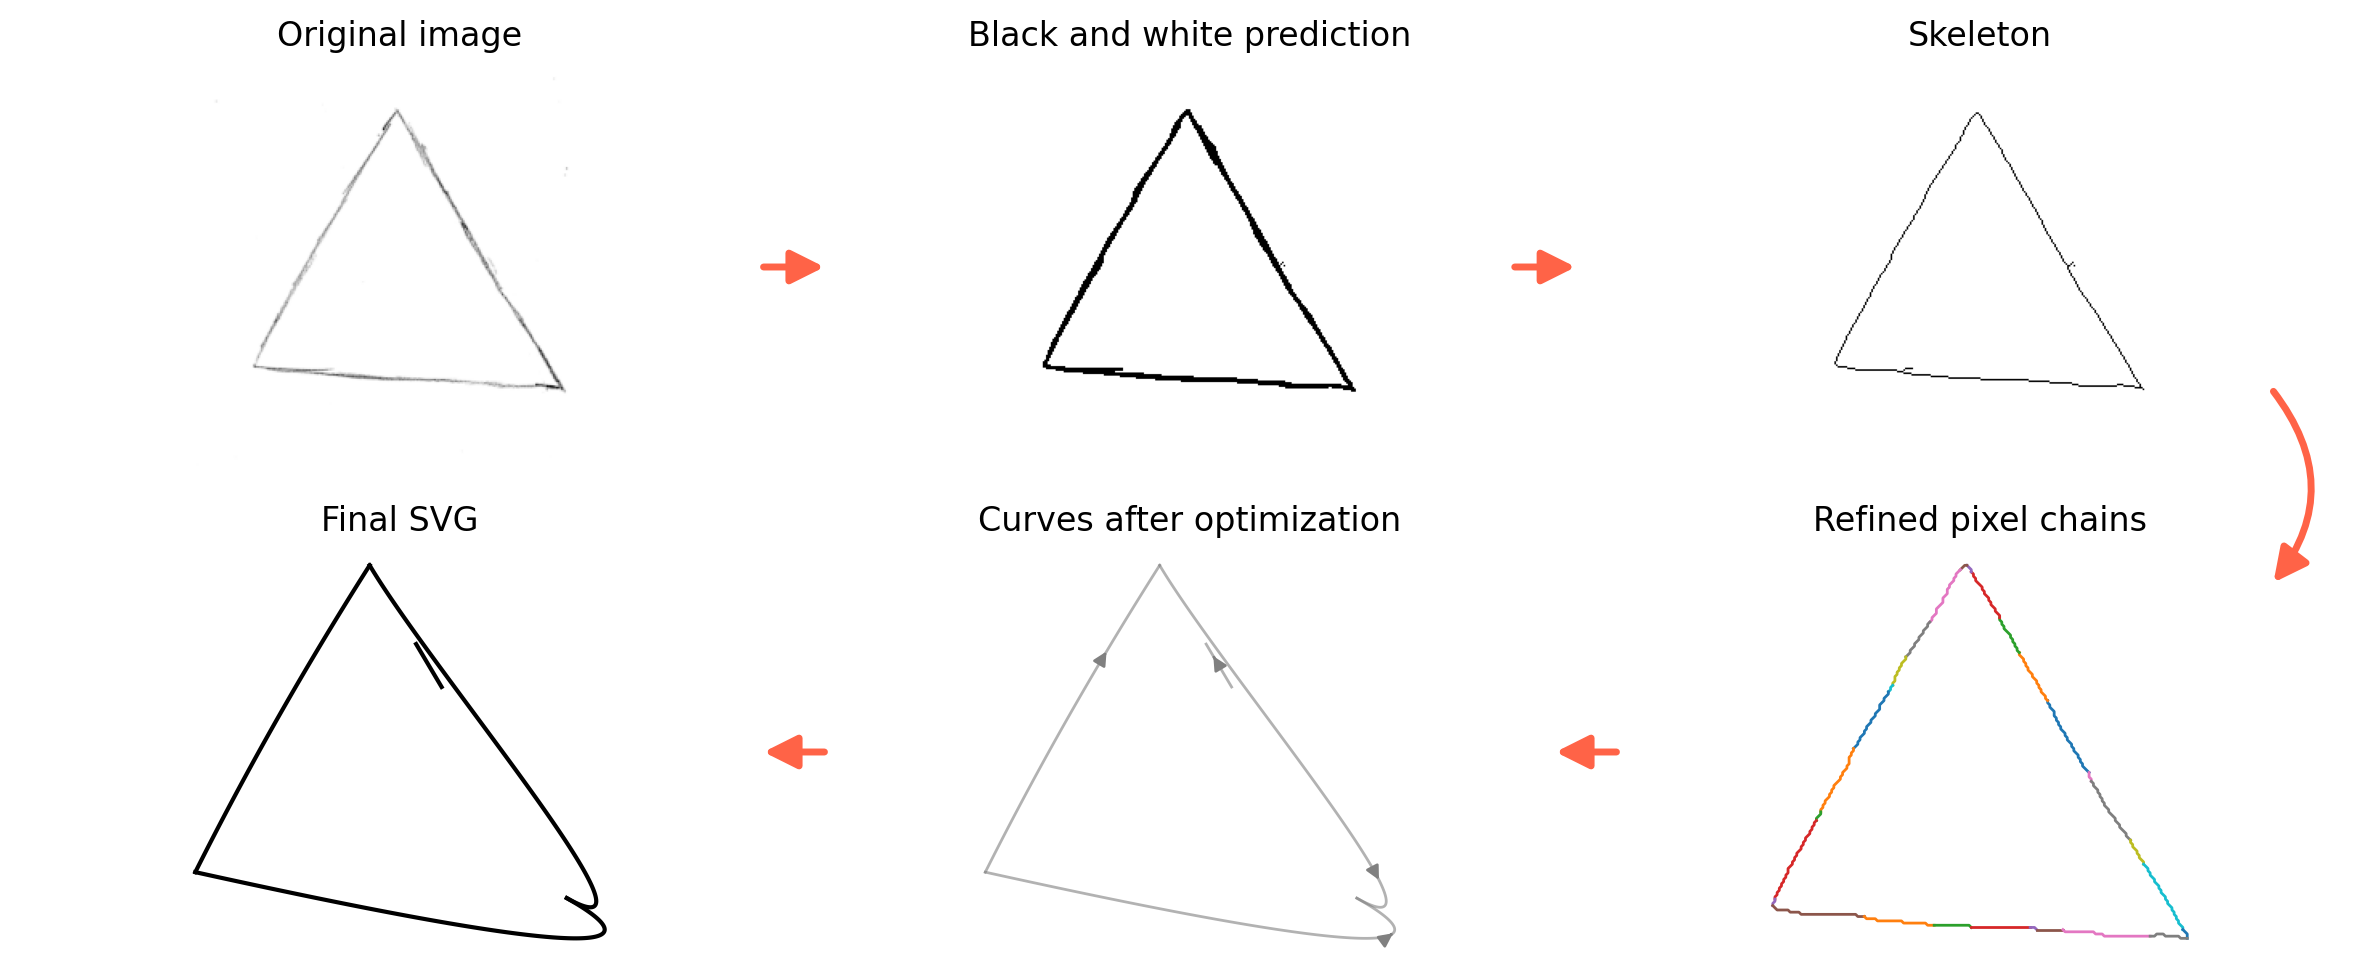

In [ ]:
show_example(ROOT_DIR / "data/sketches/triangle.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:05<00:00, 2523.66it/s]


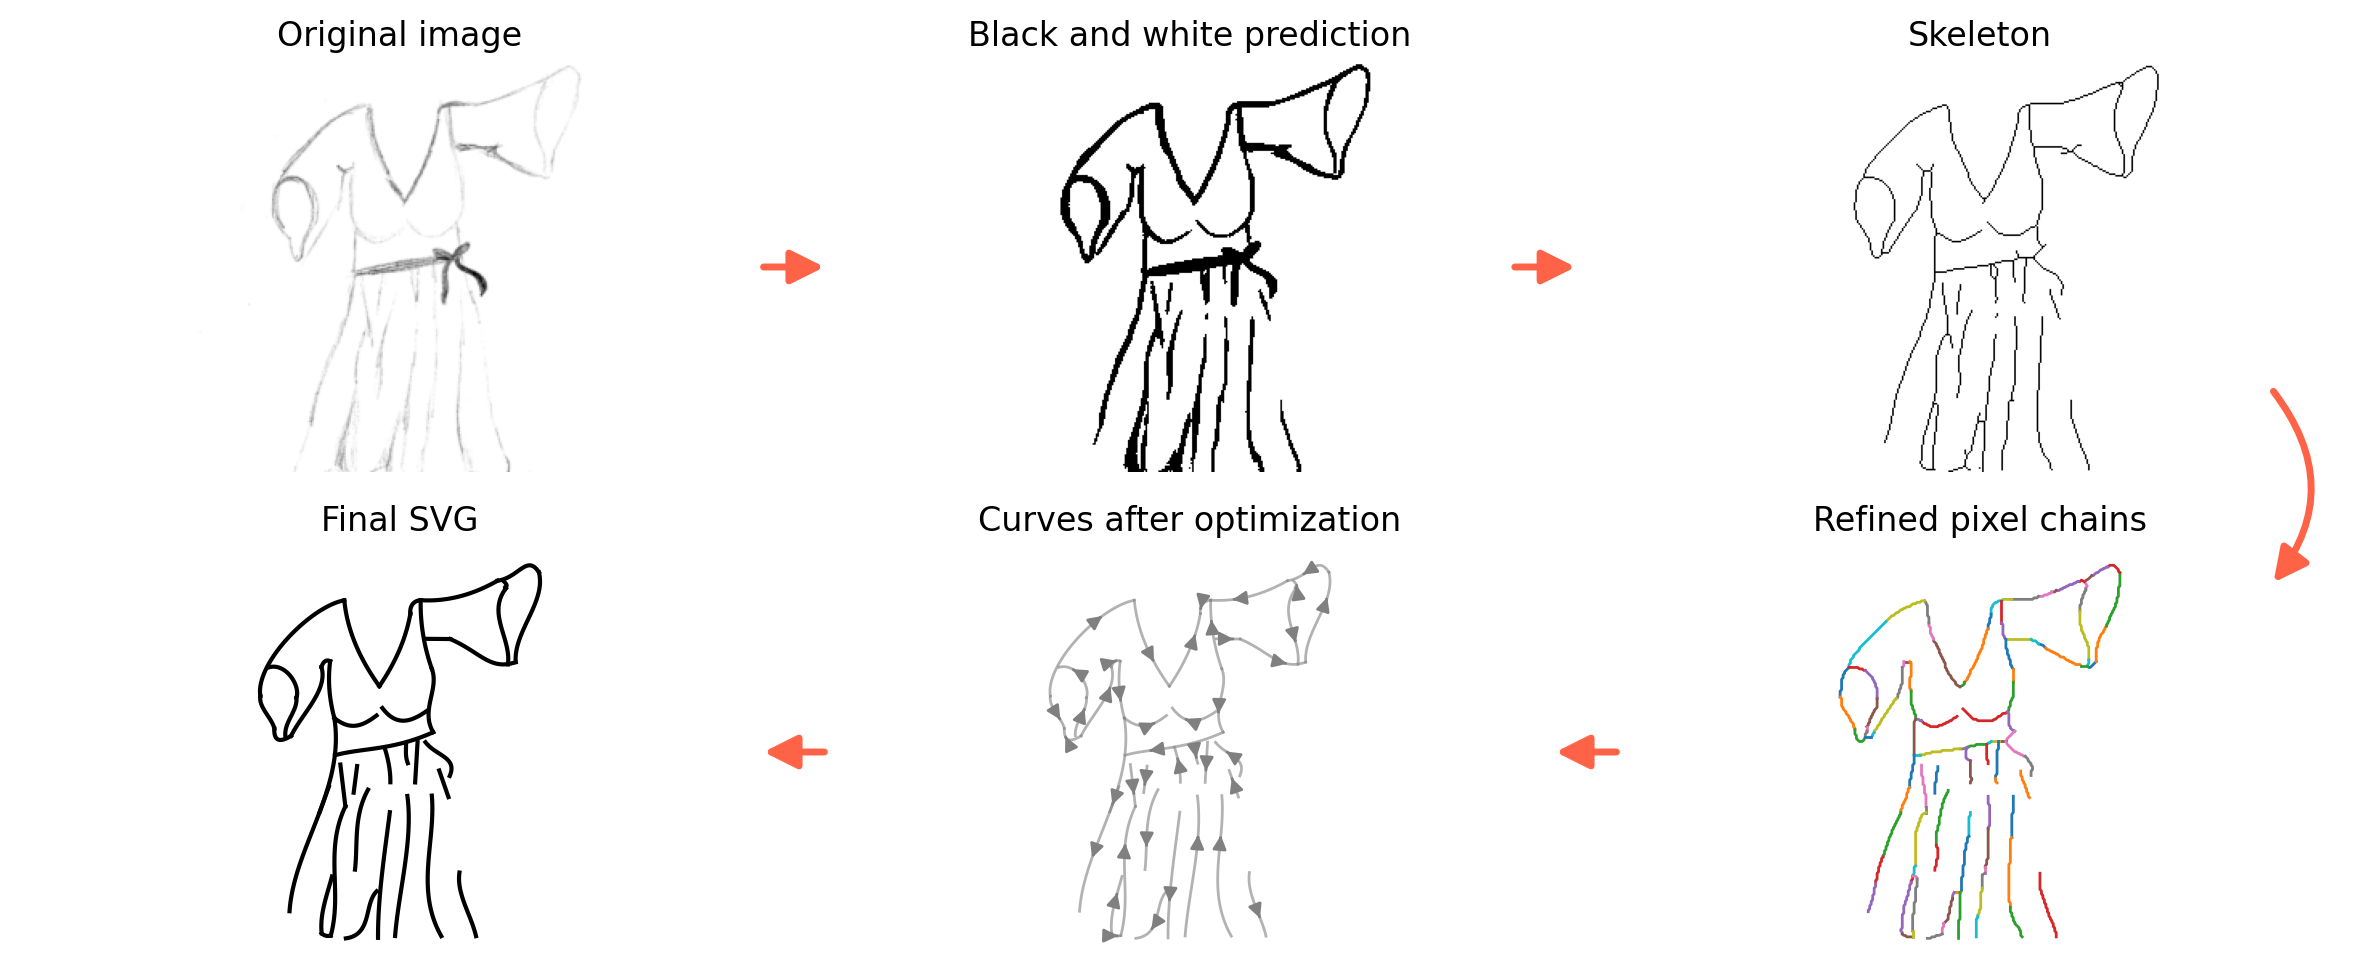

In [ ]:
show_example(ROOT_DIR / "data/sketches/dress.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:05<00:00, 2560.27it/s]


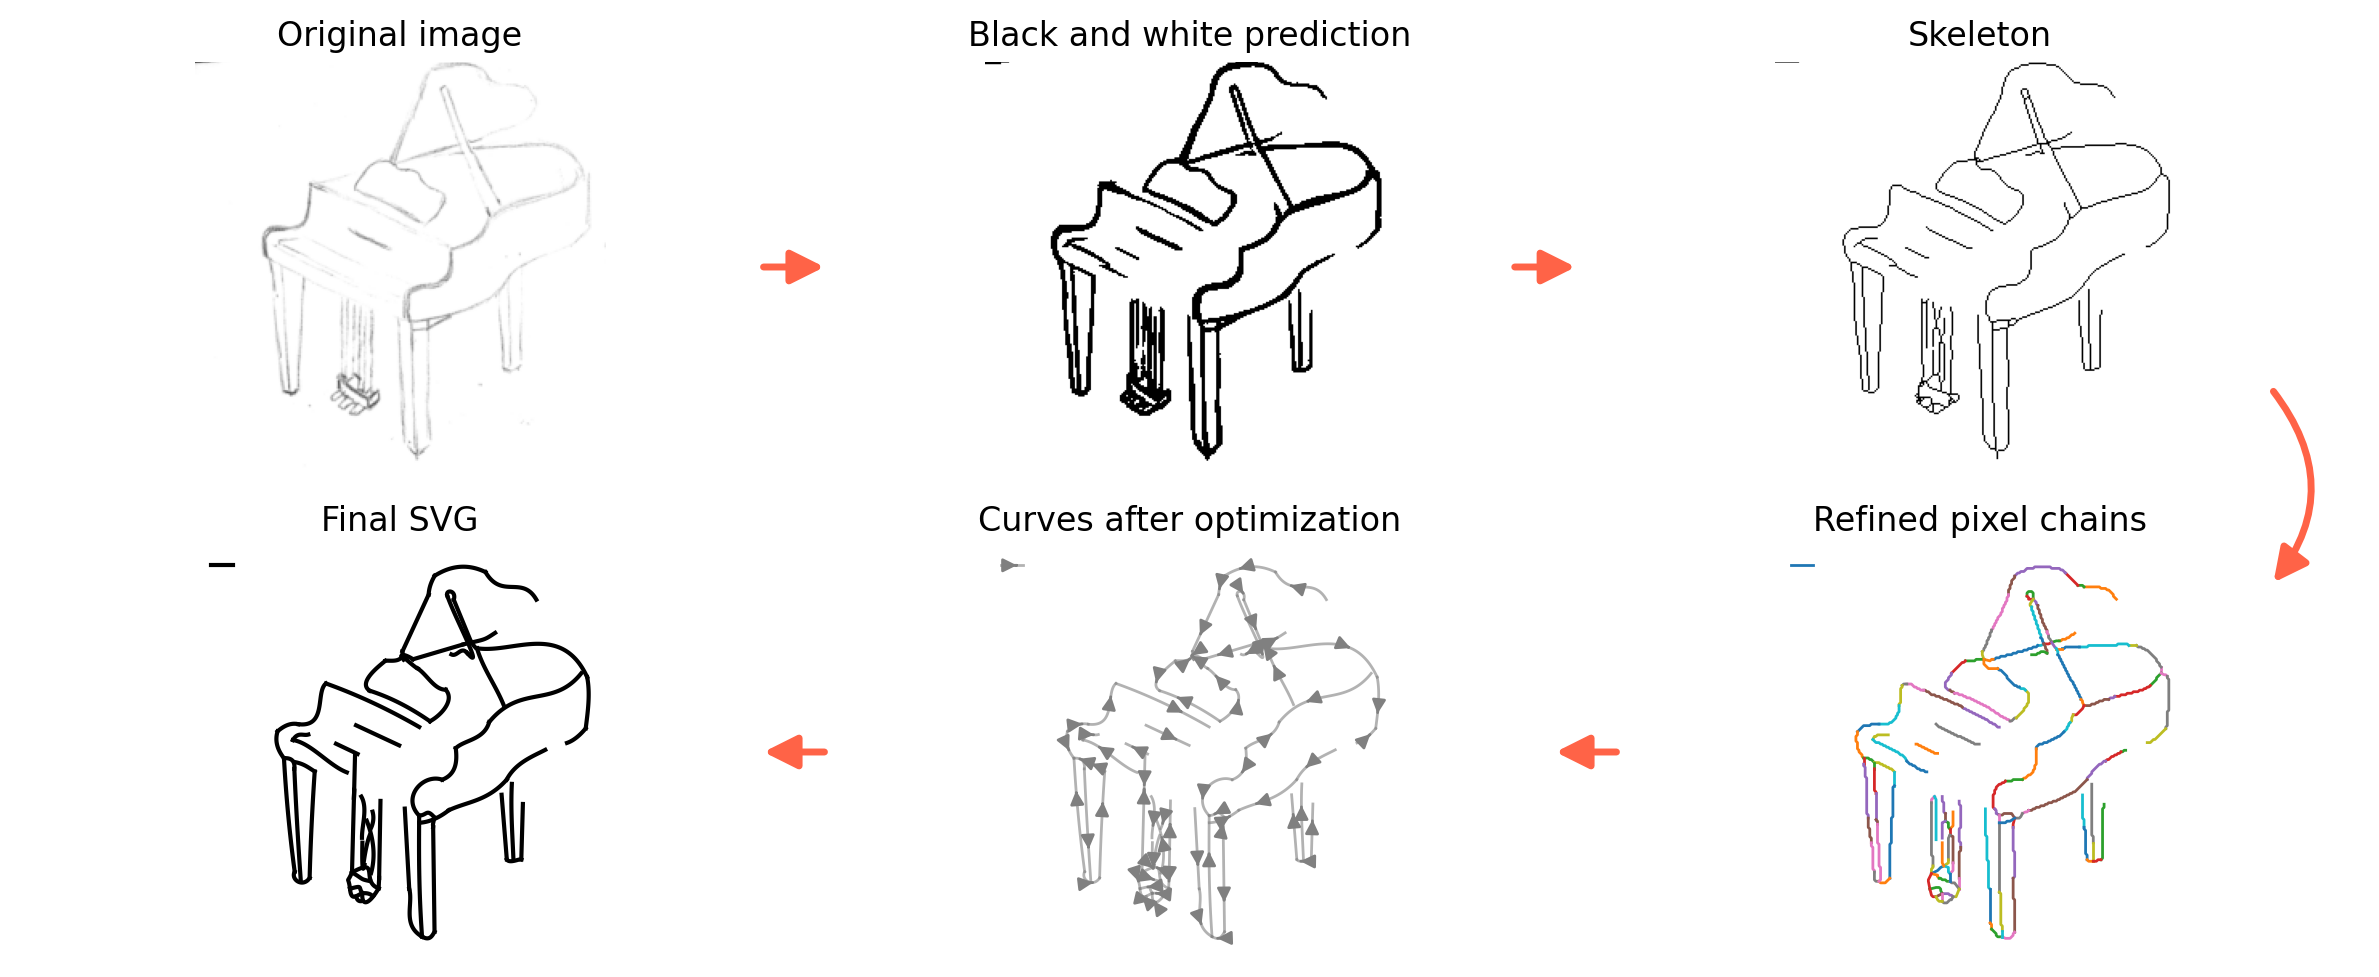

In [ ]:
show_example(ROOT_DIR / "data/sketches/piano.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:05<00:00, 2409.60it/s]


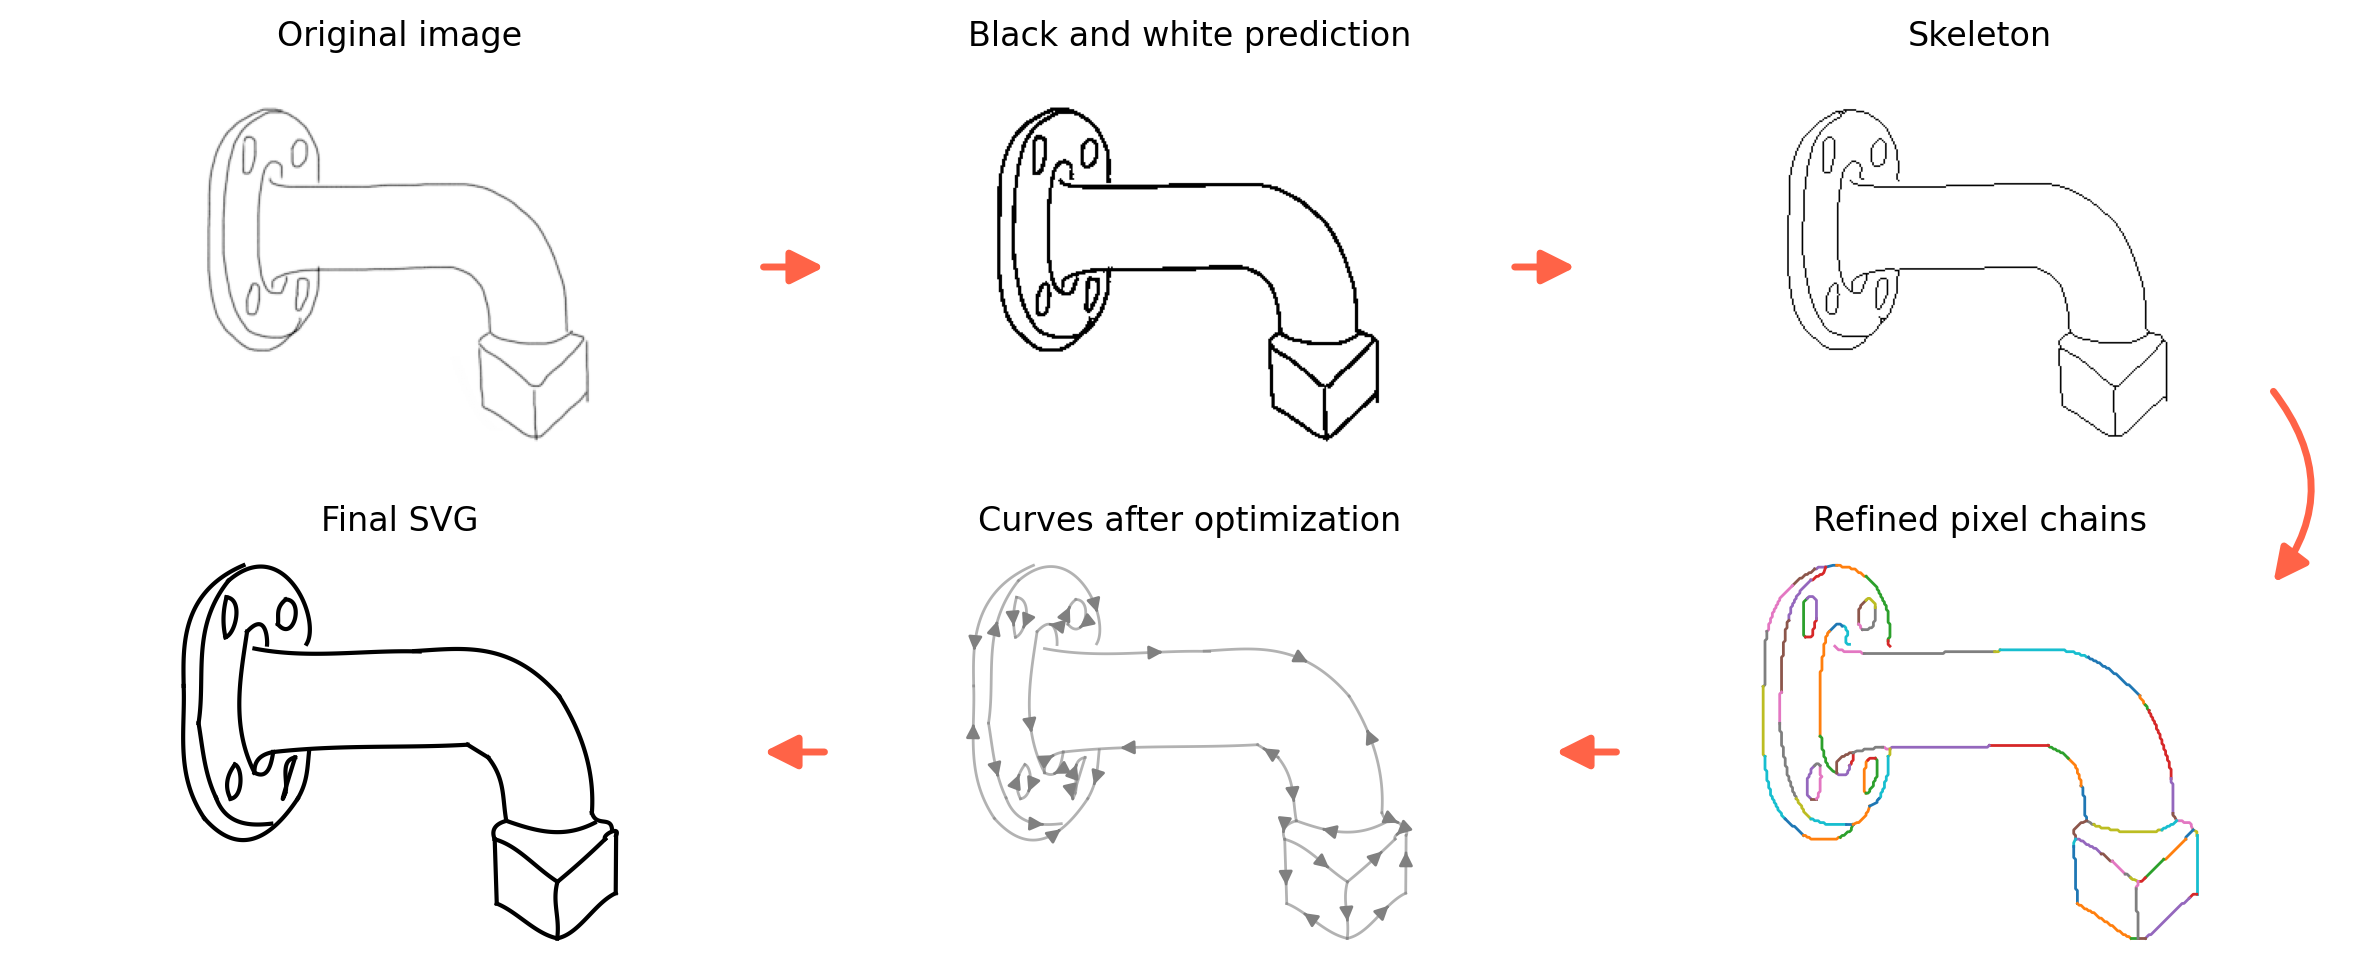

In [ ]:
show_example(
    ROOT_DIR / "data/CAD_dataset/Dataset_B/ESB_Sketches/90 degree elbows/001_1.png"
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:05<00:00, 2508.22it/s]


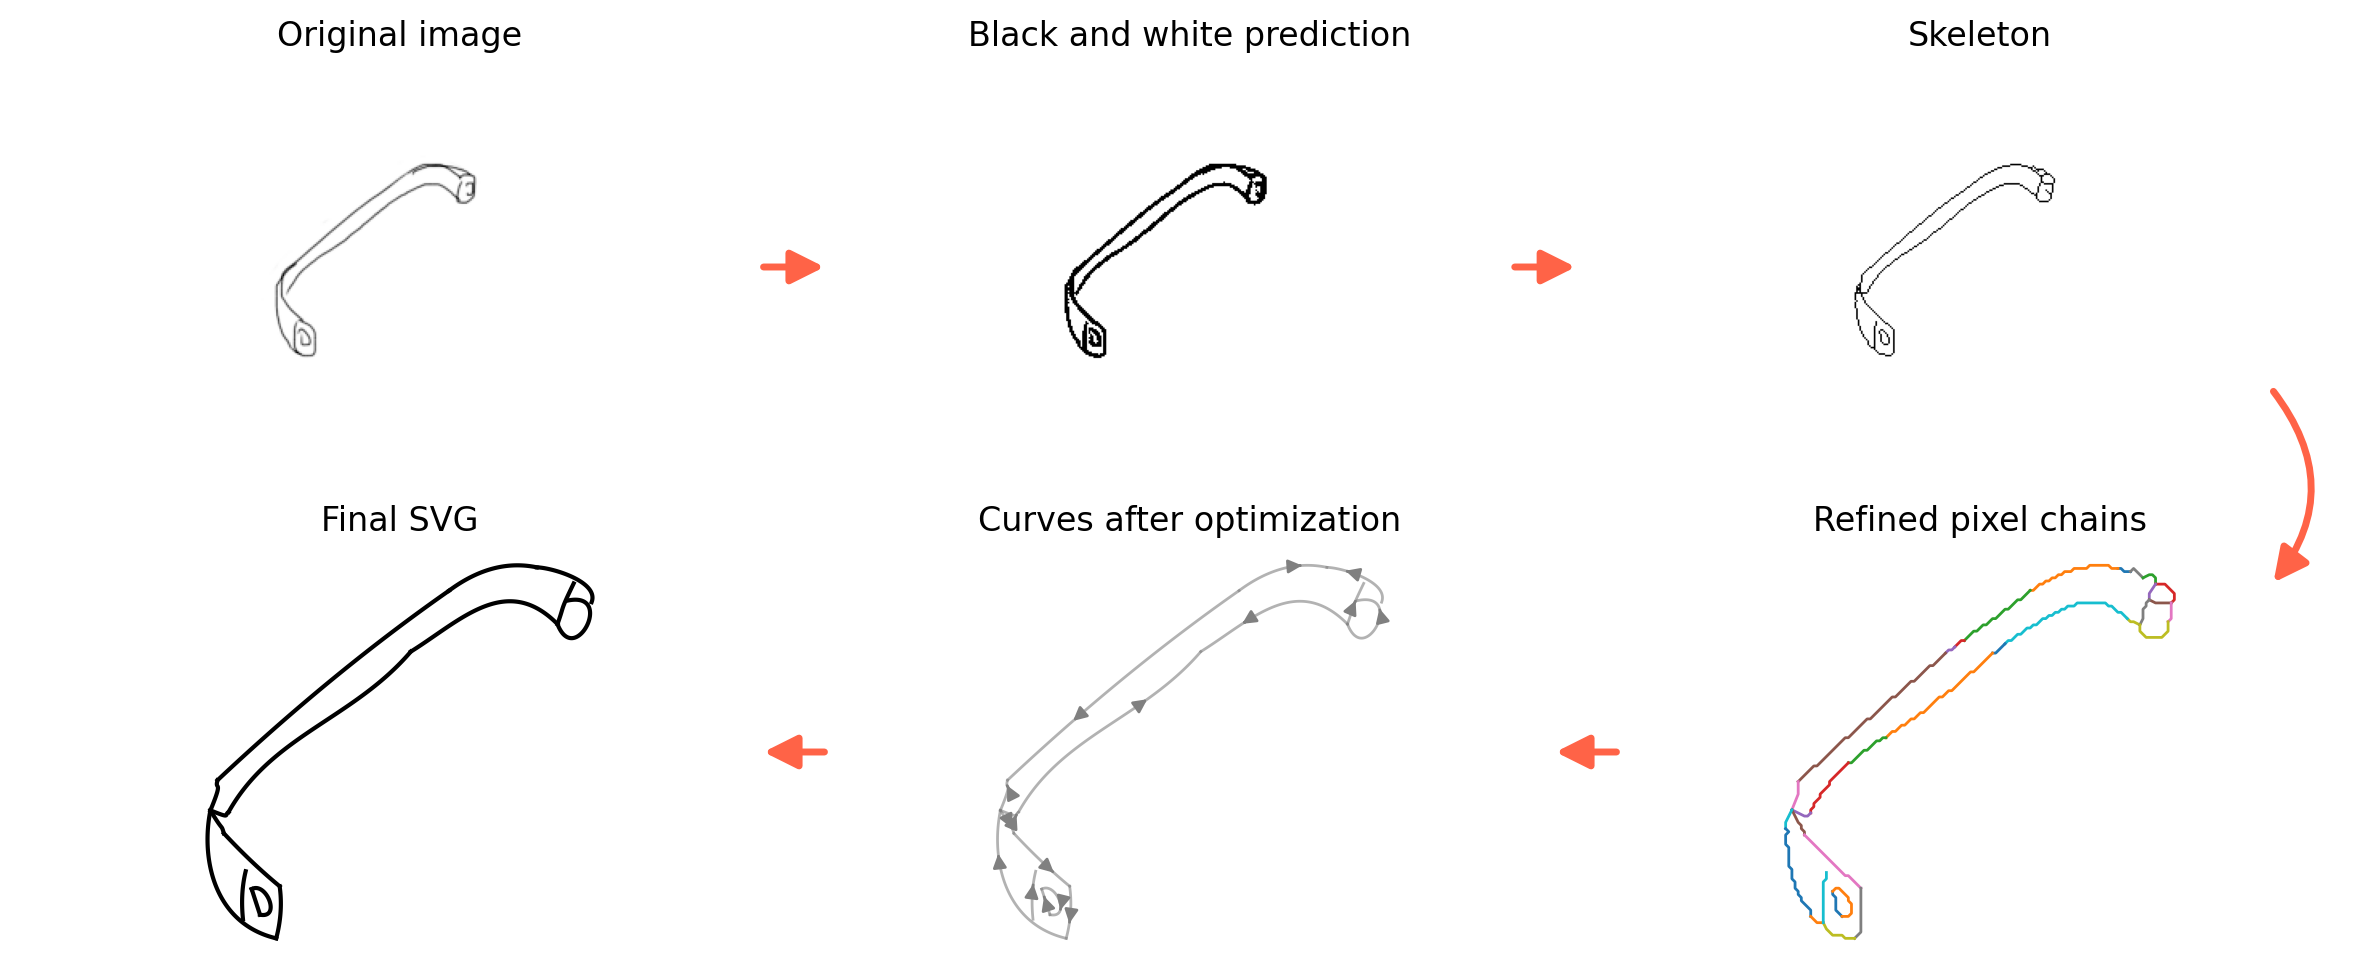

In [ ]:
show_example(
    ROOT_DIR / "data/CAD_dataset/Dataset_B/ESB_Sketches/U shaped parts/005_1.png"
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:05<00:00, 2326.04it/s]


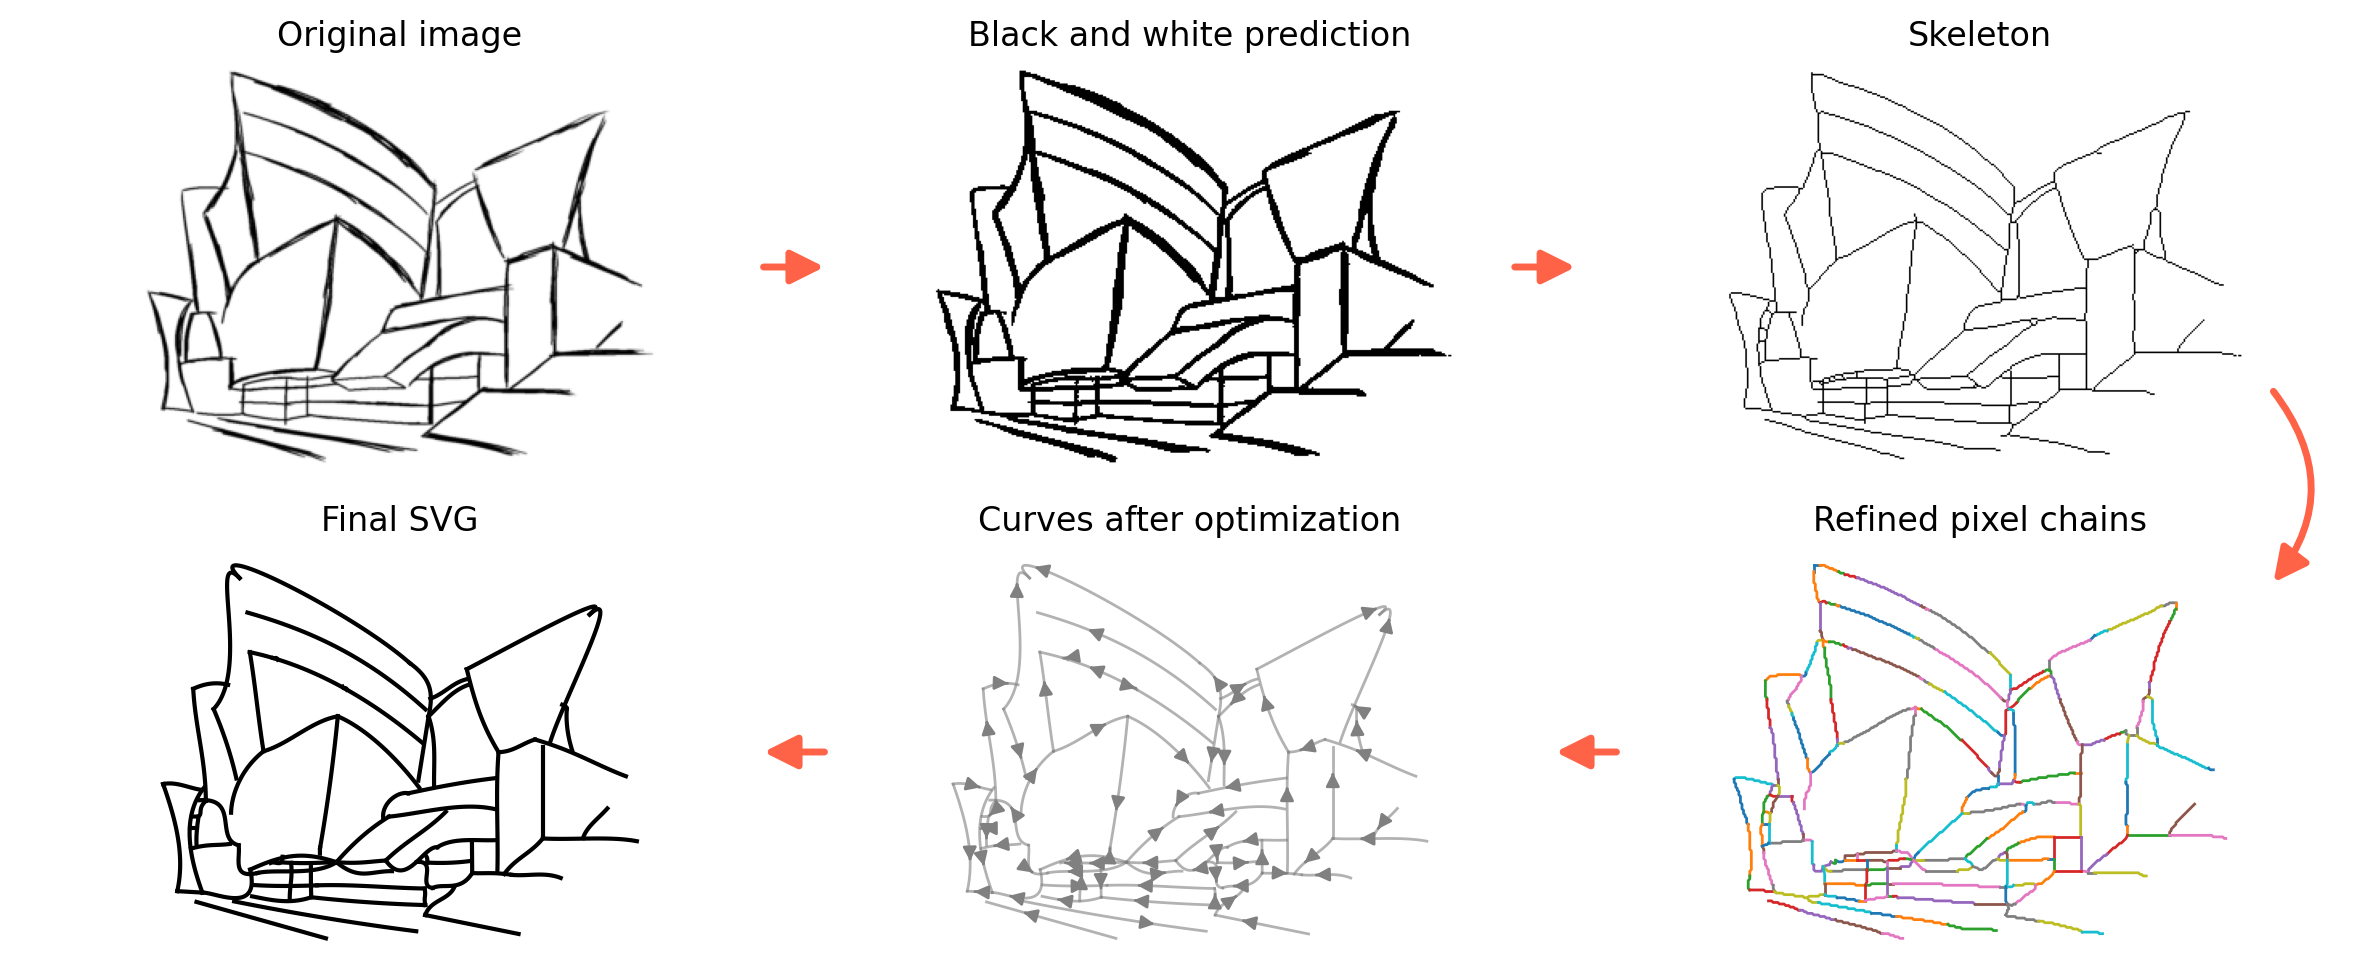

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_10/archi.png")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13862/13862 [00:06<00:00, 2261.13it/s]


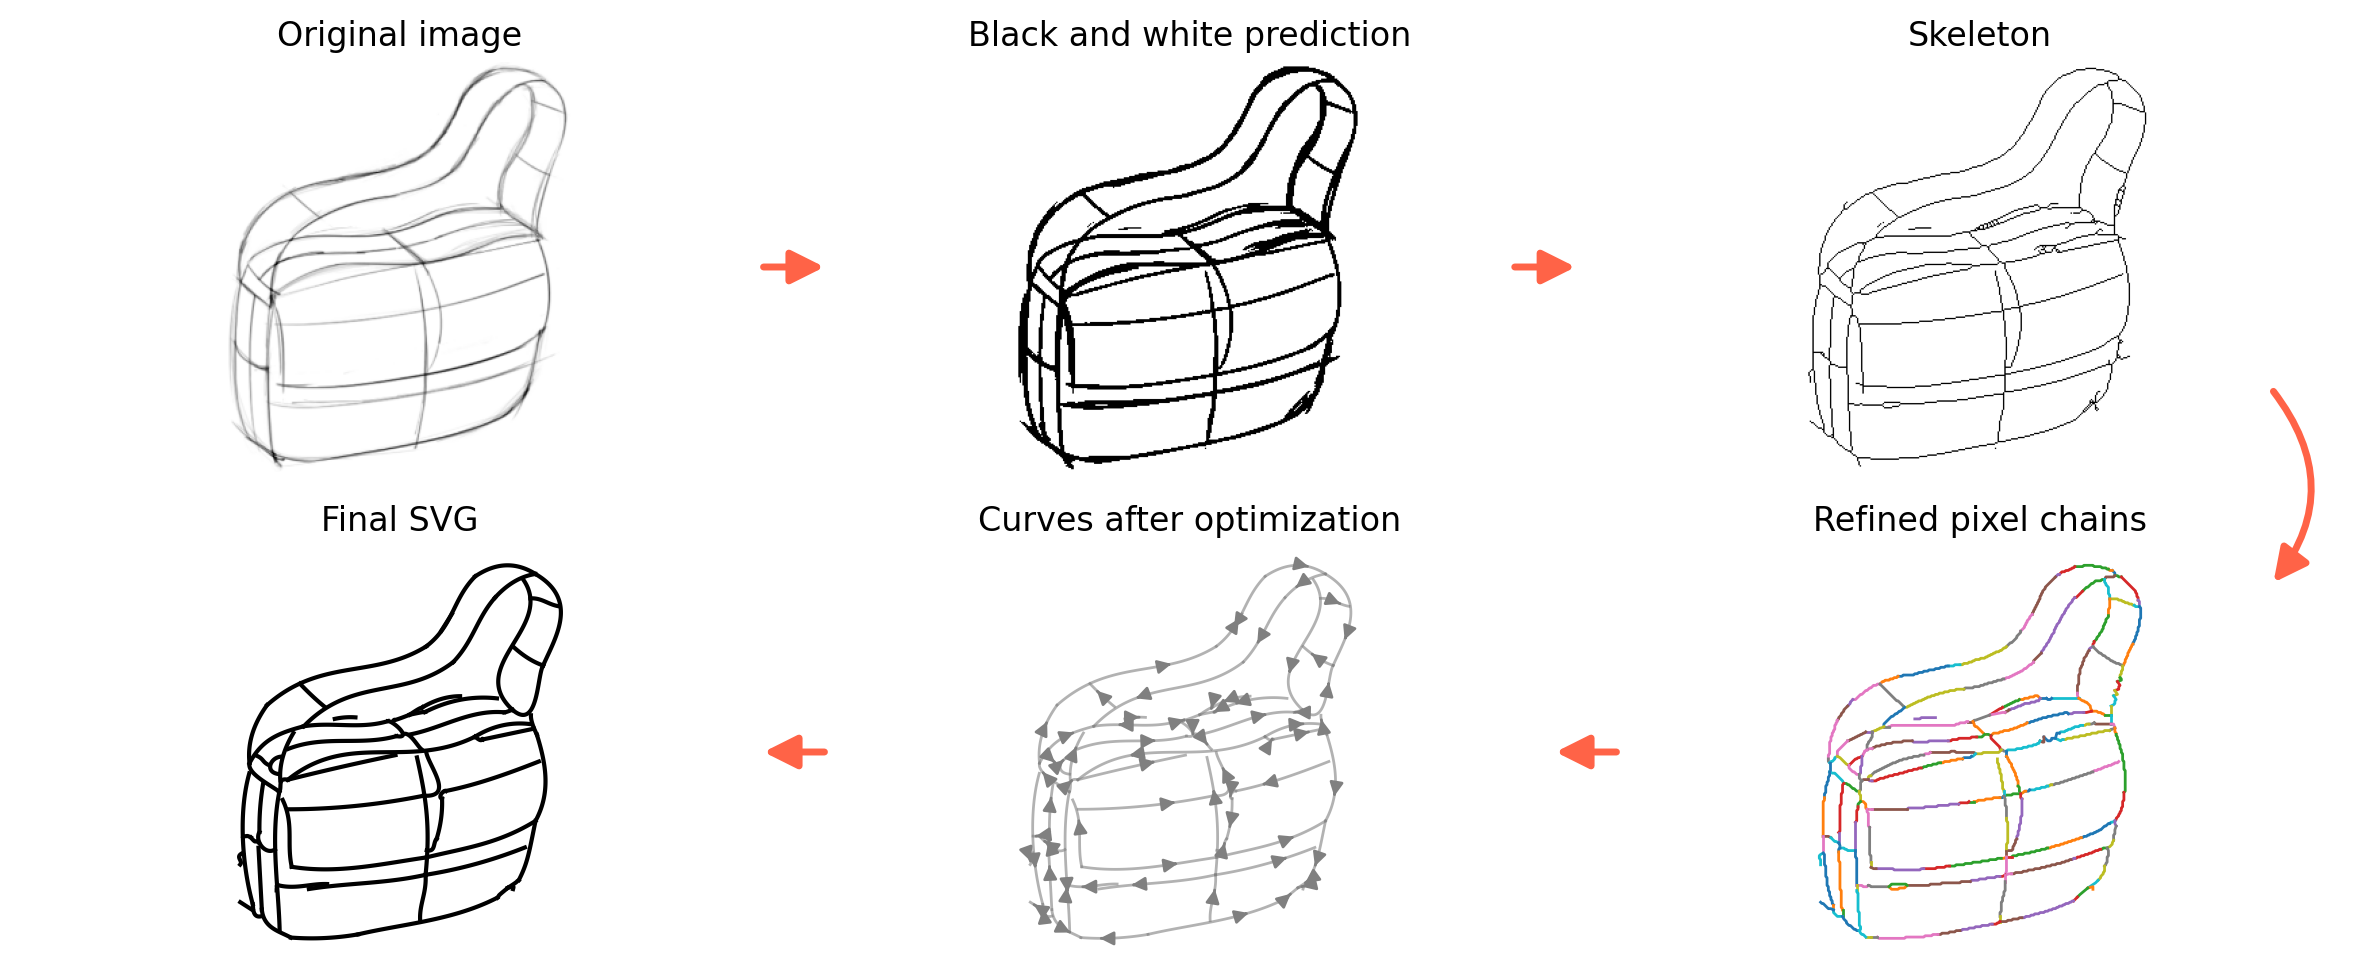

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_14/bag/input.png")